Using Colab cache for faster access to the 'indoor-object-detection' dataset.
шлях до даних: /kaggle/input/indoor-object-detection
yaml файл: /kaggle/input/indoor-object-detection/data.yaml
класи: ['door', 'cabinetDoor', 'refrigeratorDoor', 'window', 'chair', 'table', 'cabinet', 'couch', 'openedDoor', 'pole']
кількість класів: 10
створено файл: indoor_data.yaml
Ultralytics 8.4.172 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=indoor_data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.

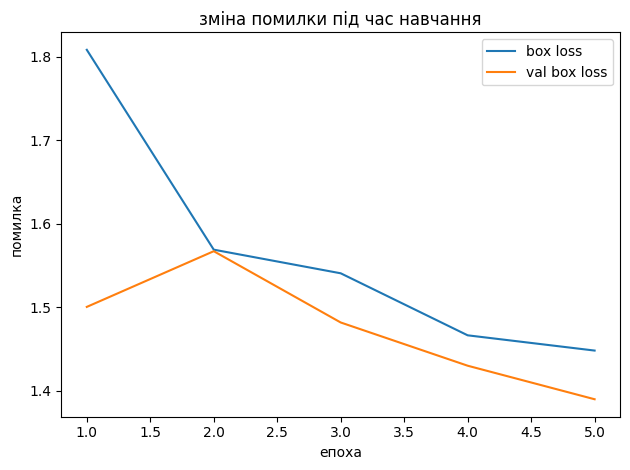

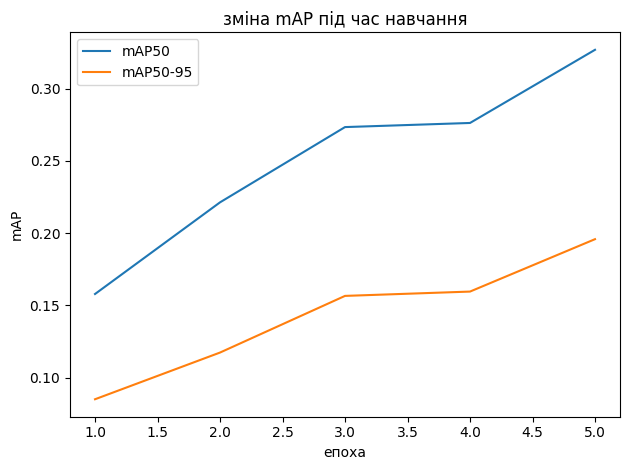


image 1/107 /kaggle/input/indoor-object-detection/test/images/1003.png: 320x416 3 cabinetDoors, 147.5ms
image 2/107 /kaggle/input/indoor-object-detection/test/images/1014.png: 320x416 1 chair, 134.5ms
image 3/107 /kaggle/input/indoor-object-detection/test/images/1015.png: 320x416 1 refrigeratorDoor, 1 chair, 132.8ms
image 4/107 /kaggle/input/indoor-object-detection/test/images/1020.png: 320x416 1 door, 1 window, 131.5ms
image 5/107 /kaggle/input/indoor-object-detection/test/images/1021.png: 320x416 (no detections), 129.5ms
image 6/107 /kaggle/input/indoor-object-detection/test/images/1023.png: 320x416 2 windows, 2 chairs, 130.2ms
image 7/107 /kaggle/input/indoor-object-detection/test/images/1026.png: 320x416 1 door, 2 windows, 2 chairs, 3 couchs, 129.5ms
image 8/107 /kaggle/input/indoor-object-detection/test/images/1027.png: 320x416 1 window, 2 chairs, 1 table, 2 couchs, 138.5ms
image 9/107 /kaggle/input/indoor-object-detection/test/images/1028.png: 320x416 1 door, 1 chair, 1 cabinet,

In [10]:
import os
import yaml
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO


#завантажуємо дані
path = kagglehub.dataset_download('thepbordin/indoor-object-detection')

print('шлях до даних:', path)


#знаходимо файл yaml
original_yaml = ''

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.yaml'):
            original_yaml = os.path.join(root, file)
            break

    if original_yaml != '':
        break

print('yaml файл:', original_yaml)


#читаємо інформацію про класи
with open(original_yaml, 'r') as file:
    data = yaml.safe_load(file)

classes = data['names']
num_classes = len(classes)

print('класи:', classes)
print('кількість класів:', num_classes)


#знаходимо правильні шляхи до зображень
def get_split_path(split_name):
    for root, dirs, files in os.walk(path):
        if os.path.basename(root) == split_name:
            if 'images' in dirs:
                return os.path.join(root, 'images')
            return root
    return ''

train_dir = get_split_path('train')
val_dir = get_split_path('valid') or get_split_path('val')
test_dir = get_split_path('test')


#створюємо свій yaml файл
data_yaml = 'indoor_data.yaml'

new_data = {'train': train_dir, 'val': val_dir, 'test': test_dir, 'names': classes}

with open(data_yaml, 'w') as file:
    yaml.dump(new_data, file, sort_keys=False)

print('створено файл:', data_yaml)


#створюємо модель YOLOv9s
model = YOLO('yolov9s.pt')


#навчаємо модель
results = model.train(data=data_yaml, epochs=5, imgsz=416, batch=8, device='cpu', project='runs', name='indoor_yolov9')


#перевіряємо модель на тестових даних
metrics = model.val(data=data_yaml, split='test', imgsz=416, batch=8, device='cpu', plots=True)


#виводимо загальні результати
print('\nрезультати:')
print('Precision:', metrics.box.mp)
print('Recall:', metrics.box.mr)
print('mAP50:', metrics.box.map50)
print('mAP50-95:', metrics.box.map)


#виводимо результати для кожного класу
print('\nрезультати по класах:')

precision = metrics.box.p
recall = metrics.box.r
f1 = metrics.box.f1

for i in range(num_classes):
    print(classes[i], 'Precision:', round(precision[i], 4), 'Recall:', round(recall[i], 4), 'F1:', round(f1[i], 4))


#будуємо графіки навчання
results_path = os.path.join(results.save_dir, 'results.csv')

results_data = pd.read_csv(results_path)

results_data.columns = results_data.columns.str.strip()

plt.plot(results_data['epoch'], results_data['train/box_loss'], label='box loss')
plt.plot(results_data['epoch'], results_data['val/box_loss'], label='val box loss')
plt.xlabel('епоха')
plt.ylabel('помилка')
plt.title('зміна помилки під час навчання')
plt.legend()
plt.tight_layout()
plt.savefig('loss.png')
plt.show()


#будуємо графік mAP
plt.plot(results_data['epoch'], results_data['metrics/mAP50(B)'], label='mAP50')
plt.plot(results_data['epoch'], results_data['metrics/mAP50-95(B)'], label='mAP50-95')
plt.xlabel('епоха')
plt.ylabel('mAP')
plt.title('зміна mAP під час навчання')
plt.legend()
plt.tight_layout()
plt.savefig('map.png')
plt.show()


#робимо прогноз на тестових зображеннях
test_path = test_dir

predictions = model.predict(source=test_path, imgsz=416, conf=0.25, device='cpu', save=True)

print('\nпрогнози збережено')


#показуємо матрицю помилок
confusion_matrix_path = os.path.join(metrics.save_dir, 'confusion_matrix.png')

if os.path.exists(confusion_matrix_path):
    print('матриця помилок:', confusion_matrix_path)